In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

inventory = pd.read_csv("../data/inventory_snapshots.csv")

print("Inventory dataset shape:", inventory.shape)
print(inventory.head())

Inventory dataset shape: (4800, 8)
  Snapshot_Date     SKU  Current_Stock  On_Order  Lead_Time_Days  \
0    2024-01-01  SKU001             16        23              11   
1    2024-01-01  SKU002             29        12               4   
2    2024-01-01  SKU003             34        23              14   
3    2024-01-01  SKU004             34         4               7   
4    2024-01-01  SKU005             23         5               5   

   Safety_Stock  Reorder_Point  Inventory_Value  
0             7             18         58420.96  
1             5             10        163983.40  
2             6             20        209060.22  
3             5             12         42257.92  
4             6             11        170945.89  


In [2]:
inventory["Snapshot_Date"] = pd.to_datetime(
    inventory["Snapshot_Date"]
)

print("Date Range:")
print(inventory["Snapshot_Date"].min())
print(inventory["Snapshot_Date"].max())

print("\nMissing Values:")
print(inventory.isnull().sum())

print("\nUnique SKUs:", inventory["SKU"].nunique())

Date Range:
2024-01-01 00:00:00
2025-12-01 00:00:00

Missing Values:
Snapshot_Date      0
SKU                0
Current_Stock      0
On_Order           0
Lead_Time_Days     0
Safety_Stock       0
Reorder_Point      0
Inventory_Value    0
dtype: int64

Unique SKUs: 200


In [3]:
sales = pd.read_csv("../data/sales_daily.csv")

sales_skus = set(sales["SKU"].unique())
inventory_skus = set(inventory["SKU"].unique())

print("Sales SKUs:", len(sales_skus))
print("Inventory SKUs:", len(inventory_skus))

print("Matching SKUs:", len(sales_skus & inventory_skus))
print("Sales SKUs missing in inventory:", len(sales_skus - inventory_skus))
print("Inventory SKUs missing in sales:", len(inventory_skus - sales_skus))

Sales SKUs: 50
Inventory SKUs: 200
Matching SKUs: 50
Sales SKUs missing in inventory: 0
Inventory SKUs missing in sales: 150


In [4]:
latest_date = inventory["Snapshot_Date"].max()

latest_inventory = inventory[
    inventory["Snapshot_Date"] == latest_date
].copy()

print("Latest Snapshot Date:", latest_date)
print("Latest Inventory Shape:", latest_inventory.shape)

print(latest_inventory.head())

Latest Snapshot Date: 2025-12-01 00:00:00
Latest Inventory Shape: (200, 8)
     Snapshot_Date     SKU  Current_Stock  On_Order  Lead_Time_Days  \
4600    2025-12-01  SKU001            771       147               4   
4601    2025-12-01  SKU002            526        29               3   
4602    2025-12-01  SKU003            349        12               3   
4603    2025-12-01  SKU004            259       254               6   
4604    2025-12-01  SKU005            471       291               6   

      Safety_Stock  Reorder_Point  Inventory_Value  
4600           159            289       2815160.01  
4601            94            149       2974319.60  
4602            88            123       2145941.67  
4603            98            196        321905.92  
4604           129            245       3500674.53  


In [5]:
matched_inventory = latest_inventory[
    latest_inventory["SKU"].isin(sales_skus)
].copy()

print("Matched Inventory Shape:", matched_inventory.shape)
print(matched_inventory.head())

Matched Inventory Shape: (50, 8)
     Snapshot_Date     SKU  Current_Stock  On_Order  Lead_Time_Days  \
4600    2025-12-01  SKU001            771       147               4   
4601    2025-12-01  SKU002            526        29               3   
4602    2025-12-01  SKU003            349        12               3   
4603    2025-12-01  SKU004            259       254               6   
4604    2025-12-01  SKU005            471       291               6   

      Safety_Stock  Reorder_Point  Inventory_Value  
4600           159            289       2815160.01  
4601            94            149       2974319.60  
4602            88            123       2145941.67  
4603            98            196        321905.92  
4604           129            245       3500674.53  


In [6]:
print("Total SKUs:", matched_inventory["SKU"].nunique())

print(
    "Duplicate SKU records:",
    matched_inventory["SKU"].duplicated().sum()
)

Total SKUs: 50
Duplicate SKU records: 0


In [7]:
matched_inventory["Below_Reorder_Point"] = (
    matched_inventory["Current_Stock"]
    <= matched_inventory["Reorder_Point"]
)

print(
    matched_inventory[
        ["SKU", "Current_Stock", "Reorder_Point", "Below_Reorder_Point"]
    ].head(10)
)

print(
    "\nProducts below reorder point:",
    matched_inventory["Below_Reorder_Point"].sum()
)

         SKU  Current_Stock  Reorder_Point  Below_Reorder_Point
4600  SKU001            771            289                False
4601  SKU002            526            149                False
4602  SKU003            349            123                False
4603  SKU004            259            196                False
4604  SKU005            471            245                False
4605  SKU006            359            340                False
4606  SKU007            207            237                 True
4607  SKU008            325            161                False
4608  SKU009             75            131                 True
4609  SKU010             83             60                False

Products below reorder point: 15


In [8]:
matched_inventory["Stock_Position"] = (
    matched_inventory["Current_Stock"]
    + matched_inventory["On_Order"]
)

matched_inventory["Below_Reorder_Point_After_Order"] = (
    matched_inventory["Stock_Position"]
    <= matched_inventory["Reorder_Point"]
)

print(
    matched_inventory[
        [
            "SKU",
            "Current_Stock",
            "On_Order",
            "Stock_Position",
            "Reorder_Point",
            "Below_Reorder_Point_After_Order"
        ]
    ].head(10)
)

print(
    "\nProducts below reorder point after considering incoming stock:",
    matched_inventory["Below_Reorder_Point_After_Order"].sum()
)

         SKU  Current_Stock  On_Order  Stock_Position  Reorder_Point  \
4600  SKU001            771       147             918            289   
4601  SKU002            526        29             555            149   
4602  SKU003            349        12             361            123   
4603  SKU004            259       254             513            196   
4604  SKU005            471       291             762            245   
4605  SKU006            359       485             844            340   
4606  SKU007            207       460             667            237   
4607  SKU008            325       155             480            161   
4608  SKU009             75        89             164            131   
4609  SKU010             83        70             153             60   

      Below_Reorder_Point_After_Order  
4600                            False  
4601                            False  
4602                            False  
4603                            False  
4604   

In [9]:
remaining_risk = matched_inventory[
    matched_inventory["Below_Reorder_Point_After_Order"]
].copy()

print(
    remaining_risk[
        [
            "SKU",
            "Current_Stock",
            "On_Order",
            "Stock_Position",
            "Reorder_Point",
            "Safety_Stock",
            "Lead_Time_Days"
        ]
    ]
)

         SKU  Current_Stock  On_Order  Stock_Position  Reorder_Point  \
4616  SKU017             95        26             121            274   
4627  SKU028            174        55             229            337   

      Safety_Stock  Lead_Time_Days  
4616           108              12  
4627           114              11  


In [10]:
sales["Date"] = pd.to_datetime(sales["Date"])

weekly_sales = (
    sales.groupby(
        ["SKU", pd.Grouper(key="Date", freq="W-SUN")]
    )["Units_Sold"]
    .sum()
    .reset_index()
)

print("Weekly Sales Shape:", weekly_sales.shape)
print(weekly_sales.head())

Weekly Sales Shape: (5250, 3)
      SKU       Date  Units_Sold
0  SKU001 2024-01-07         106
1  SKU001 2024-01-14          85
2  SKU001 2024-01-21         117
3  SKU001 2024-01-28          89
4  SKU001 2024-02-04         119


In [11]:
average_demand = (
    weekly_sales.groupby("SKU")["Units_Sold"]
    .mean()
    .reset_index()
)

average_demand = average_demand.rename(
    columns={"Units_Sold": "Avg_Weekly_Demand"}
)

print(average_demand.head(10))

      SKU  Avg_Weekly_Demand
0  SKU001         100.019048
1  SKU002          70.590476
2  SKU003          40.133333
3  SKU004          32.190476
4  SKU005         116.152381
5  SKU006          45.580952
6  SKU007         172.657143
7  SKU008         113.752381
8  SKU009          74.571429
9  SKU010         118.676190


In [12]:
risk_analysis = remaining_risk.merge(
    average_demand,
    on="SKU",
    how="left"
)

risk_analysis["Daily_Demand"] = (
    risk_analysis["Avg_Weekly_Demand"] / 7
)

risk_analysis["Lead_Time_Demand"] = (
    risk_analysis["Daily_Demand"]
    * risk_analysis["Lead_Time_Days"]
)

print(
    risk_analysis[
        [
            "SKU",
            "Stock_Position",
            "Lead_Time_Days",
            "Avg_Weekly_Demand",
            "Lead_Time_Demand"
        ]
    ].round(2)
)

      SKU  Stock_Position  Lead_Time_Days  Avg_Weekly_Demand  Lead_Time_Demand
0  SKU017             121              12              98.80            169.37
1  SKU028             229              11              39.06             61.38


In [13]:
risk_analysis["Days_of_Cover"] = (
    risk_analysis["Stock_Position"]
    / risk_analysis["Daily_Demand"]
)

risk_analysis["Coverage_Risk"] = np.where(
    risk_analysis["Days_of_Cover"] < risk_analysis["Lead_Time_Days"],
    "High Risk",
    "Covered"
)

print(
    risk_analysis[
        [
            "SKU",
            "Stock_Position",
            "Days_of_Cover",
            "Lead_Time_Days",
            "Coverage_Risk"
        ]
    ].round(2)
)

      SKU  Stock_Position  Days_of_Cover  Lead_Time_Days Coverage_Risk
0  SKU017             121           8.57              12     High Risk
1  SKU028             229          41.04              11       Covered


In [14]:
matched_inventory["Days_of_Cover"] = (
    matched_inventory["Stock_Position"]
    / matched_inventory["SKU"].map(
        average_demand.set_index("SKU")["Avg_Weekly_Demand"]
    ).div(7)
)

matched_inventory["Risk_Status"] = np.select(
    [
        matched_inventory["Days_of_Cover"] < matched_inventory["Lead_Time_Days"],
        matched_inventory["Stock_Position"] <= matched_inventory["Reorder_Point"]
    ],
    [
        "High Risk",
        "Reorder Attention"
    ],
    default="Healthy"
)

print(matched_inventory["Risk_Status"].value_counts())

Risk_Status
Healthy              44
High Risk             5
Reorder Attention     1
Name: count, dtype: int64


In [15]:
high_risk_products = matched_inventory[
    matched_inventory["Risk_Status"] == "High Risk"
].copy()

print(
    high_risk_products[
        [
            "SKU",
            "Current_Stock",
            "On_Order",
            "Stock_Position",
            "Lead_Time_Days",
            "Days_of_Cover",
            "Reorder_Point"
        ]
    ].round(2)
)

         SKU  Current_Stock  On_Order  Stock_Position  Lead_Time_Days  \
4609  SKU010             83        70             153              13   
4611  SKU012             47        60             107              12   
4616  SKU017             95        26             121              12   
4630  SKU031             93        40             133              13   
4639  SKU040             67        29              96               9   

      Days_of_Cover  Reorder_Point  
4609           9.02             60  
4611           4.12             58  
4616           8.57            274  
4630           7.12            113  
4639           6.19             93  


In [16]:
high_risk_products = high_risk_products.merge(
    average_demand,
    on="SKU",
    how="left"
)

high_risk_products["Daily_Demand"] = (
    high_risk_products["Avg_Weekly_Demand"] / 7
)

high_risk_products["Lead_Time_Demand"] = (
    high_risk_products["Daily_Demand"]
    * high_risk_products["Lead_Time_Days"]
)

high_risk_products["Estimated_Shortfall"] = (
    high_risk_products["Lead_Time_Demand"]
    - high_risk_products["Stock_Position"]
).clip(lower=0)

print(
    high_risk_products[
        [
            "SKU",
            "Stock_Position",
            "Lead_Time_Demand",
            "Estimated_Shortfall"
        ]
    ].round(2)
)

      SKU  Stock_Position  Lead_Time_Demand  Estimated_Shortfall
0  SKU010             153            220.40                67.40
1  SKU012             107            311.30               204.30
2  SKU017             121            169.37                48.37
3  SKU031             133            242.68               109.68
4  SKU040              96            139.57                43.57


In [17]:
sku_master = pd.read_csv("../data/sku_master.csv")

print("SKU Master Shape:", sku_master.shape)
print(sku_master.columns.tolist())
print(sku_master.head())

SKU Master Shape: (50, 8)
['SKU', 'Product_Name', 'Category', 'Subcategory', 'Launch_Date', 'Cost_Price', 'Selling_Price', 'Gross_Margin_Per_Unit']
      SKU Product_Name    Category Subcategory Launch_Date  Cost_Price  \
0  SKU001  Product 001   Furniture       Chair  2022-04-09     1758.45   
1  SKU002  Product 002  Home Decor       Table  2024-05-01     3867.09   
2  SKU003  Product 003     Kitchen     Cushion  2023-12-22      589.48   
3  SKU004  Product 004    Lighting    Cookware  2023-04-28     1445.74   
4  SKU005  Product 005     Storage        Lamp  2023-04-22     5543.63   

   Selling_Price  Gross_Margin_Per_Unit  
0        3664.05                1905.60  
1        3805.69                 -61.40  
2        8078.23                7488.75  
3        6861.57                5415.83  
4        9493.22                3949.59  


In [18]:
high_risk_products = high_risk_products.merge(
    sku_master[
        [
            "SKU",
            "Product_Name",
            "Selling_Price",
            "Gross_Margin_Per_Unit"
        ]
    ],
    on="SKU",
    how="left"
)

print(
    high_risk_products[
        [
            "SKU",
            "Product_Name",
            "Estimated_Shortfall",
            "Selling_Price",
            "Gross_Margin_Per_Unit"
        ]
    ].round(2)
)

      SKU Product_Name  Estimated_Shortfall  Selling_Price  \
0  SKU010  Product 010                67.40         663.46   
1  SKU012  Product 012               204.30        8779.37   
2  SKU017  Product 017                48.37        8477.32   
3  SKU031  Product 031               109.68        8715.93   
4  SKU040  Product 040                43.57        2450.56   

   Gross_Margin_Per_Unit  
0               -3225.60  
1                7522.48  
2                1774.06  
3                2415.28  
4               -2718.51  


In [19]:
high_risk_products["Potential_Revenue_Exposure"] = (
    high_risk_products["Estimated_Shortfall"]
    * high_risk_products["Selling_Price"]
)

high_risk_products["Potential_Margin_Exposure"] = (
    high_risk_products["Estimated_Shortfall"]
    * high_risk_products["Gross_Margin_Per_Unit"]
)

print(
    high_risk_products[
        [
            "SKU",
            "Estimated_Shortfall",
            "Potential_Revenue_Exposure",
            "Potential_Margin_Exposure"
        ]
    ].round(2)
)

print(
    "\nTotal Potential Revenue Exposure:",
    round(high_risk_products["Potential_Revenue_Exposure"].sum(), 2)
)

print(
    "Net Potential Gross-Margin Exposure:",
    round(high_risk_products["Potential_Margin_Exposure"].sum(), 2)
)

      SKU  Estimated_Shortfall  Potential_Revenue_Exposure  \
0  SKU010                67.40                    44716.30   
1  SKU012               204.30                  1793607.37   
2  SKU017                48.37                   410060.08   
3  SKU031               109.68                   956001.15   
4  SKU040                43.57                   106764.40   

   Potential_Margin_Exposure  
0                 -217401.05  
1                 1536827.31  
2                   85813.82  
3                  264918.43  
4                 -118438.27  

Total Potential Revenue Exposure: 3311149.3
Net Potential Gross-Margin Exposure: 1551720.23


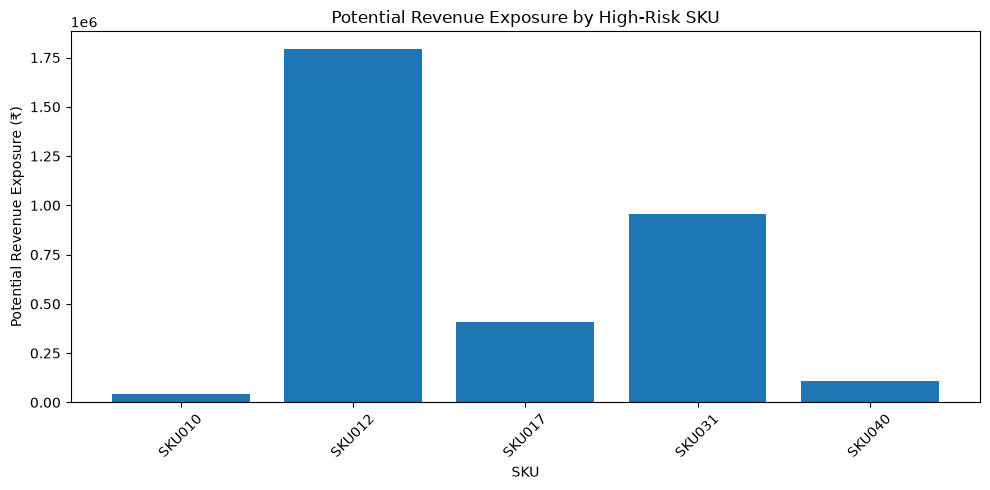

In [20]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))

plt.bar(
    high_risk_products["SKU"],
    high_risk_products["Potential_Revenue_Exposure"]
)

plt.title("Potential Revenue Exposure by High-Risk SKU")
plt.xlabel("SKU")
plt.ylabel("Potential Revenue Exposure (₹)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Inventory Risk Analysis — Key Findings

- Analyzed 50 SKUs common to sales and inventory datasets.
- 15 products were initially below their reorder point.
- After including incoming stock, 2 products remained below their reorder point.
- Demand-based analysis identified 5 products with estimated stock coverage shorter than supplier lead time.
- SKU012 had the shortest coverage among the five high-risk products (4.12 days against a 12-day lead time).
- Combined estimated demand shortfall across high-risk products was 473.32 units.
- Potential revenue exposure was approximately ₹33.11 lakh.
- Net potential gross-margin exposure was approximately ₹15.52 lakh.

Note: These are preliminary estimates based on average historical demand and the December 1, 2025 inventory snapshot. They are not confirmed stockouts or realized financial losses.